In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
df = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [2]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


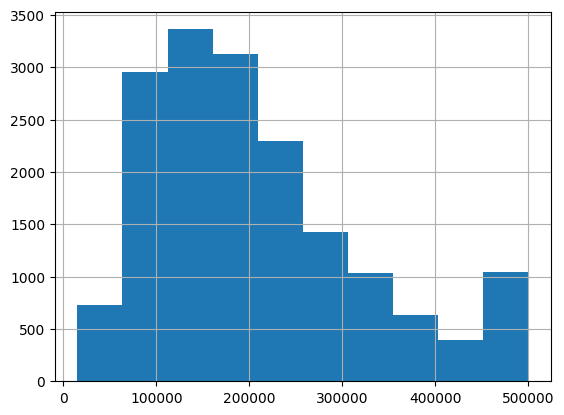

In [3]:
import matplotlib.pyplot as plt

df['median_house_value'].hist()
plt.show()

In [4]:
# create a new target variable for SMOTE
import numpy as np

# nice imbalanced data!
df['median_house_value'] = np.where(df['median_house_value'] < 380000, 1, 0)
df['median_house_value'].value_counts()

,count
median_house_value,
1,15304
0,1696


#Minority Undersampling

In [5]:
# Split data into train and test
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']
validation_size = 0.20
seed = 123

# split!
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=validation_size, random_state=seed)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((13600, 8), (3400, 8), (13600,), (3400,))

In [21]:
# Majority Undersampling
undersample = RandomUnderSampler(sampling_strategy='majority')
X_train_under, Y_train_under = undersample.fit_resample(X_train, Y_train)
print(X_train_under.shape, Y_train_under.shape)
#print(X_train_under.value_counts())
print(Y_train_under.value_counts())

(2692, 8) (2692,)
median_house_value
0    1346
1    1346
Name: count, dtype: int64


In [26]:
# Fit the model to X_train_under and Y_train_under
model = LogisticRegression(random_state=seed,max_iter=1000)
model.fit(X_train_under, Y_train_under)

LogisticRegression(max_iter=1000, random_state=123)

In [27]:
predictions = model.predict(X_test)

In [28]:
#num_folds = 10
#kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
print(classification_report(predictions,Y_test))

              precision    recall  f1-score   support

           0       0.88      0.40      0.55       773
           1       0.85      0.98      0.91      2627

    accuracy                           0.85      3400
   macro avg       0.87      0.69      0.73      3400
weighted avg       0.86      0.85      0.83      3400



In [29]:
print(confusion_matrix(predictions,Y_test))

[[ 309  464]
 [  41 2586]]


# SMOTE

In [37]:
sm = SMOTENC(categorical_features = [7], random_state=seed)
X_res, y_res = sm.fit_resample(X, y)
print(X_res.shape, y_res.shape)
print(y_res.value_counts())

(30608, 8) (30608,)
median_house_value
1    15304
0    15304
Name: count, dtype: int64
